# 02 - Baselines: stored numbers and a reproduction check

The stored results in `data/results/` come from `bash .runs/run_all.sh`-style runs (see
`scripts/reproduce.sh`). This notebook tabulates them, plots them, and re-evaluates two baselines on
a few held-out seeds to show that the stored numbers reproduce exactly (the metrics are
deterministic given scenario, seed and policy).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, functools
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from rl_flatland.plotting import load_rows, plot_results, plot_training, POLICY_LABEL
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
rows = load_rows(ROOT / "data" / "results")
df = pd.DataFrame(rows)
print(len(df), "episodes;", sorted(df.policy.unique()))

560 episodes; ['bc', 'bc_ppo', 'or_pp_sipp', 'ppo', 'ppo_tree', 'reactive_avoid', 'shortest_path']


In [2]:
summary = (df.groupby(["policy", "split", "scenario"])
             [["arrival_rate", "normalized_reward", "deadlocked", "decision_ms_mean", "setup_s"]]
             .mean().round(3))
summary

arrival_rate  normalized_reward  \
policy         split            scenario                                    
bc             test             large            0.130              0.658   
                                medium           0.180              0.679   
                                small            0.390              0.734   
                                xlarge           0.079              0.623   
               test_malfunction large            0.152              0.660   
                                medium           0.197              0.677   
                                small            0.410              0.741   
                                xlarge           0.082              0.595   
bc_ppo         test             large            0.133              0.646   
                                medium           0.237              0.700   
                                small            0.630              0.823   
                                xlarge           0.064              0.614   
               test_malfunction large            0.153              0.654   
                                medium           0.207              0.676   
                                small            0.610              0.821   
                                xlarge           0.069              0.611   
or_pp_sipp     test             large            0.982              0.972   
                                medium           0.993              0.991   
                                small            1.000              0.995   
                                xlarge           0.957              0.953   
               test_malfunction large            0.938              0.952   
                                medium           0.980              0.984   
                                small            1.000              0.991   
                                xlarge           0.891              0.922   
ppo            test             large            0.143              0.626   
                                medium           0.350              0.724   
                                small            0.600              0.810   
                                xlarge           0.075              0.582   
               test_malfunction large            0.142              0.633   
                                medium           0.360              0.729   
                                small            0.600              0.804   
                                xlarge           0.075              0.580   
ppo_tree       test             large            0.165              0.744   
                                medium           0.247              0.751   
                                small            0.250              0.664   
                                xlarge           0.160              0.737   
               test_malfunction large            0.163              0.742   
                                medium           0.227              0.747   
                                small            0.220              0.656   
                                xlarge           0.150              0.732   
reactive_avoid test             large            0.253              0.689   
                                medium           0.463              0.766   
                                small            0.820              0.885   
                                xlarge           0.111              0.615   
               test_malfunction large            0.223              0.679   
                                medium           0.457              0.761   
                                small            0.760              0.867   
                                xlarge           0.098              0.612   
shortest_path  test             large            0.083              0.564   
                                medium           0.247              0.656   
                                small 

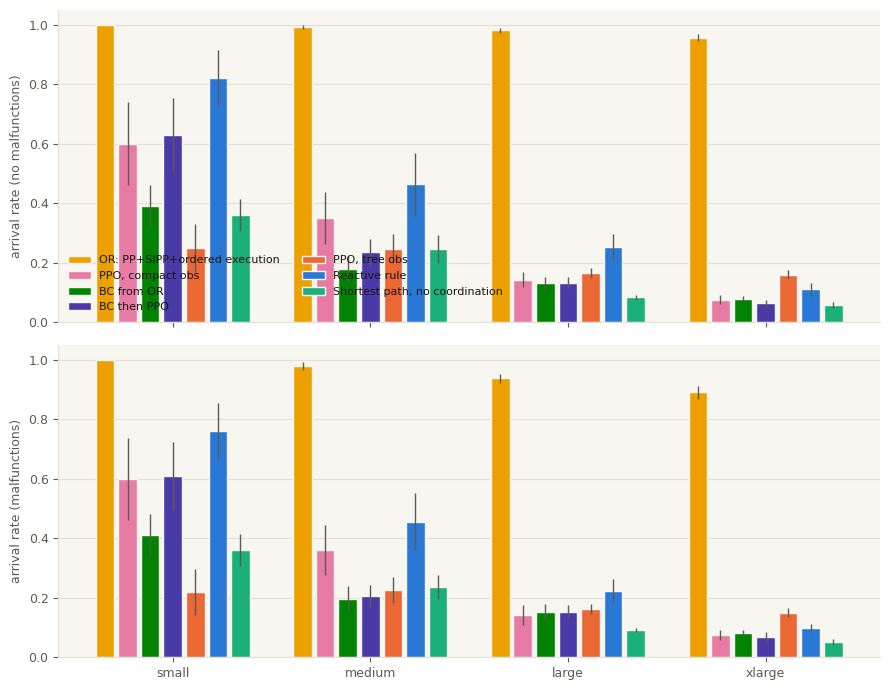

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
plot_results(rows, "arrival_rate", "test", ax=axes[0], ylabel="arrival rate (no malfunctions)")
plot_results(rows, "arrival_rate", "test_malfunction", ax=axes[1], ylabel="arrival rate (malfunctions)")
axes[1].get_legend().remove()
plt.tight_layout()

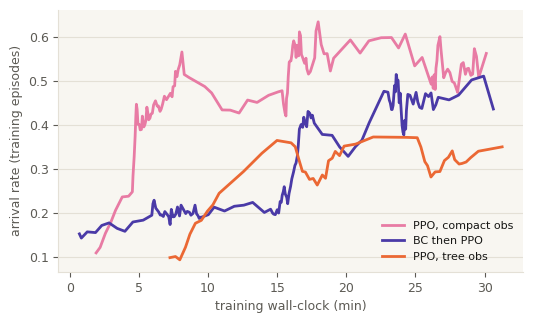

In [4]:
logs = {name: ROOT / "data" / "checkpoints" / name / "train_log.jsonl" for name in ["ppo", "bc_ppo", "ppo_tree"]}
logs = {k: v for k, v in logs.items() if v.exists()}
plot_training(logs);

## Reproduce a slice of the stored numbers

Re-run the OR reference and PPO on the first three held-out seeds of the small scenario and
compare with the stored rows. Arrival rate, normalised reward and deadlocks must match exactly;
decision times will not (they depend on the machine and its load).

In [5]:
import sys; sys.path.insert(0, str(ROOT / "scripts"))
from evaluate import make_policy
from rl_flatland.evaluation import evaluate
fresh = []
fresh += evaluate(functools.partial(make_policy, "or"), ["small"], ["test", "test_malfunction"], n_seeds=3, workers=1)
ckpt = ROOT / "data" / "checkpoints" / "ppo" / "model.pt"
if ckpt.exists():
    fresh += evaluate(functools.partial(make_policy, "network", str(ckpt), "compact", "ppo"), ["small"], ["test", "test_malfunction"], n_seeds=3, workers=1)
stored = {(r["policy"], r["scenario"], r["split"], r["seed"]): r for r in rows}
check = pd.DataFrame([dict(policy=r["policy"], split=r["split"], seed=r["seed"],
                           arrival_fresh=r["arrival_rate"], arrival_stored=stored[(r["policy"], r["scenario"], r["split"], r["seed"])]["arrival_rate"],
                           reward_fresh=round(r["normalized_reward"], 4), reward_stored=round(stored[(r["policy"], r["scenario"], r["split"], r["seed"])]["normalized_reward"], 4))
                      for r in fresh])
check["match"] = (check.arrival_fresh == check.arrival_stored) & (check.reward_fresh == check.reward_stored)
check

,policy,split,seed,arrival_fresh,arrival_stored,reward_fresh,reward_stored,match
0,or_pp_sipp,test,1000,1.0,1.0,1.0000,1.0000,True
1,or_pp_sipp,test,1001,1.0,1.0,1.0000,1.0000,True
2,or_pp_sipp,test,1002,1.0,1.0,1.0000,1.0000,True
3,or_pp_sipp,test_malfunction,1000,1.0,1.0,1.0000,1.0000,True
4,or_pp_sipp,test_malfunction,1001,1.0,1.0,0.9945,0.9945,True
5,or_pp_sipp,test_malfunction,1002,1.0,1.0,1.0000,1.0000,True
6,ppo,test,1000,0.0,0.0,0.5828,0.5828,True
7,ppo,test,1001,1.0,1.0,0.9679,0.9679,True
8,ppo,test,1002,1.0,1.0,0.9881,0.9881,True
9,ppo,test_malfunction,1000,0.0,0.0,0.5828,0.5828,True
